In [1]:
import os
import sys

# Add project root (the folder that contains 'src') to sys.path so `from src...` works
# when running notebooks from the notebooks/ subfolder.

def find_project_root(start=os.getcwd()):
    cur = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(cur, "src")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            raise FileNotFoundError("Could not find project root containing 'src'")
        cur = parent

proj_root = find_project_root()
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
print("Added to sys.path:", proj_root)


Added to sys.path: c:\Users\Krishnendu Manna\Documents\new steup\Traffic-clusturing\city-traffic-clustering


In [24]:
from src.q_learning_agent import QLearningAgent
#from src.predictor import TrafficPredictor
from src.signal_controllers import AgentController


In [20]:
import numpy as np

class TrafficPredictor:
    def __init__(self, transition_matrix):
        self.tm = transition_matrix

    def predict(self, cluster, q_ns, q_ew, speed):
        markov = np.argmax(self.tm[cluster])

        if q_ns + q_ew > 20:
            return min(3, cluster + 1)
        if q_ns + q_ew < 5:
            return max(0, cluster - 1)

        return markov


In [17]:
import numpy as np

In [22]:
tm = np.load("C:/Users/Krishnendu Manna/Documents/new steup/Traffic-clusturing/city-traffic-clustering/results/transition_matrix.npy")
agent = QLearningAgent()
predictor = TrafficPredictor(tm)
controller = AgentController(agent, predictor)


In [2]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.traffic_environment import TrafficEnvironment
from src.q_learning_agent import QLearningAgent
from src.predictor import TrafficPredictor
from src.signal_controllers import AgentController


In [7]:
SCENARIO_DATA_PATH = "C:\\Users\\Krishnendu Manna\\Documents\\new steup\\Traffic-clusturing\\city-traffic-clustering\\data\\processed\\traffic_scenarios_from_clusters_k4.csv"
TRAFFIC_DATA_PATH = "C:\\Users\\Krishnendu Manna\\Documents\\new steup\\Traffic-clusturing\\city-traffic-clustering\\data\\processed\\bangalore_traffic_with_clusters_k4.csv"
SIGNAL_TIMINGS_PATH = "C:\\Users\\Krishnendu Manna\\Documents\\new steup\\Traffic-clusturing\\city-traffic-clustering\\data\\processed\\Bangalore_Signal_Timing_2025-11-30_19-13.csv"

In [9]:
scenarios = pd.read_csv(SCENARIO_DATA_PATH)
traffic_data = pd.read_csv(TRAFFIC_DATA_PATH)

transition_matrix = np.load("C:/Users/Krishnendu Manna/Documents/new steup/Traffic-clusturing/city-traffic-clustering/results/transition_matrix.npy")


In [13]:
env = TrafficEnvironment(scenarios, traffic_data)

agent = QLearningAgent(
        n_states=4,
        n_queue_bins=10,
        n_actions=5,
        lr=0.1,
        gamma=0.95,
        epsilon=1.0,
        decay=0.995,
        min_epsilon=0.01
)

predictor = TrafficPredictor(transition_matrix)
controller = AgentController(agent, predictor)


In [14]:
episodes = 10
steps_per_episode = 1000

episode_rewards = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    for step in range(steps_per_episode):
        cluster = env.current_cluster
        queue_ns = env.get_queue_length("ns")
        queue_ew = env.get_queue_length("ew")

        prediction = predictor.predict(
            cluster,
            queue_ns,
            queue_ew,
            env.avg_speed
        )

        action = controller.get_action(
            cluster,
            queue_ns,
            queue_ew,
            prediction
        )

        next_state, reward, _, _ = env.step(action)
        agent.learn(state, action, reward, next_state)

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    print(f"Episode {ep+1}/{episodes} | Total Reward: {total_reward:.2f}")


Episode 1/10 | Total Reward: 1324.31
Episode 2/10 | Total Reward: 1463.18
Episode 3/10 | Total Reward: 1572.51
Episode 4/10 | Total Reward: 1897.07
Episode 5/10 | Total Reward: 1992.07
Episode 4/10 | Total Reward: 1897.07
Episode 5/10 | Total Reward: 1992.07
Episode 6/10 | Total Reward: 2402.53
Episode 7/10 | Total Reward: 1623.76
Episode 6/10 | Total Reward: 2402.53
Episode 7/10 | Total Reward: 1623.76
Episode 8/10 | Total Reward: 1842.06
Episode 9/10 | Total Reward: 1605.71
Episode 10/10 | Total Reward: 2053.69
Episode 8/10 | Total Reward: 1842.06
Episode 9/10 | Total Reward: 1605.71
Episode 10/10 | Total Reward: 2053.69


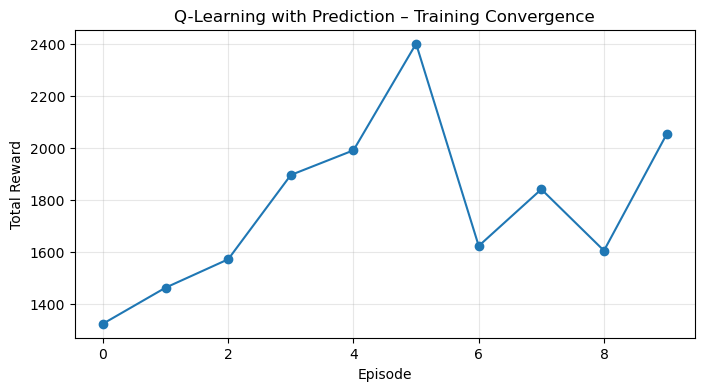

In [15]:
plt.figure(figsize=(8,4))
plt.plot(episode_rewards, marker="o")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning with Prediction – Training Convergence")
plt.grid(True, alpha=0.3)
plt.show()


In [17]:
agent.save_model("C:/Users/Krishnendu Manna/Documents/new steup/Traffic-clusturing/city-traffic-clustering/results/trained_q_agent.npy")
